In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FIELDVARS  = CONFIGS['experiments']['nn']['runs']['nn_gauss']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
EQUATIONS  = CONFIGS['experiments']['sr']['optimizedeqs']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'
CONSTNAMES = {'sr_all_eq':['c9','c10','c11'],'sr_all_pc_eq':['c12','c13','c14']}
PCNAME     = 'sr_all_pc_eq'
MIBINS     = 35
FLUXBINS   = 20
MINSAMPLES = 50
MINPRECIP  = 0.1
LANDFRAC   = 0.5
NHOURBINS  = 8
REGIONS    = {'Ocean':'#539ED4','Land':'#D42028'}
REGISTRY   = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),train_loss=row['train_loss'],valid_loss=row['valid_loss'])
              for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}

In [4]:
def kernel_integrate(fields,weights,dsig):
    return (fields*weights[None,:,:]*dsig[None,None,:]).sum(axis=2)

def calc_moisture_term(rh):
    return kappa*(rh-rhmean)

def calc_instability_term(thetae,thetaestar):
    return thetae-gamma*thetaestar-thetac

def calc_thetae_weight(lf,consts):
    return consts['lamthetae']*((consts['lfc']-lf)**3+consts['pc']*(1-consts['lfc'])**3)

def calc_correction_term(thetae,shf,lf,consts):
    return calc_thetae_weight(lf,consts)*(thetae-thetaemean)+consts['lamshf']*(consts['lfc']-lf)**3*(shf-shfmean)-consts['beta']

def to_precip(exponent):
    return np.maximum(np.expm1(exponent),0.0)

def bin_1d(x,z,edges,minsamples=MINSAMPLES):
    xi     = np.clip(np.digitize(x,edges)-1,0,len(edges)-2)
    counts = np.bincount(xi,minlength=len(edges)-1)
    sums   = np.bincount(xi,weights=z,minlength=len(edges)-1)
    return 0.5*(edges[:-1]+edges[1:]),np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)

def bin_2d(x,y,z,edges,minsamples=MINSAMPLES):
    xi     = np.clip(np.digitize(x,edges[0])-1,0,len(edges[0])-2)
    yi     = np.clip(np.digitize(y,edges[1])-1,0,len(edges[1])-2)
    shape  = (len(edges[0])-1,len(edges[1])-1)
    counts = np.zeros(shape)
    sums   = np.zeros(shape)
    np.add.at(counts,(xi,yi),1)
    np.add.at(sums,(xi,yi),z)
    return np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)

def calc_time_mean(z,finite,shape):
    return np.nanmean(np.where(finite,z,np.nan).reshape(shape),axis=0)

def calc_local_hour_bin(hours,lon,shape,nbins=NHOURBINS):
    localhour = (hours[:,None,None]+lon[None,None,:]/15.0)%24
    return (np.broadcast_to(localhour,shape).ravel()//(24/nbins)).astype(int)

def bin_by_hour(hourbin,z,mask,nbins=NHOURBINS):
    counts = np.bincount(hourbin[mask],minlength=nbins)
    sums   = np.bincount(hourbin[mask],weights=z[mask],minlength=nbins)
    return sums/np.maximum(counts,1)

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
c3,c4,c5 = (REGISTRY['sr_atm_eq']['constants'][name] for name in ['c3','c4','c5'])

lam        = STATS['tp_std']*c3/STATS['thetae_std']**3
gamma      = c4*STATS['thetae_std']/STATS['thetaestar_std']
thetac     = STATS['thetae_mean']-gamma*STATS['thetaestar_mean']+c5*STATS['thetae_std']
kappa      = STATS['thetae_std']/STATS['rh_std']
rhmean     = STATS['rh_mean']
thetaemean = STATS['thetae_mean']
shfmean    = STATS['shf_mean']

consts = {}
for name,keys in CONSTNAMES.items():
    cshf,clfc,cbeta = (REGISTRY[name]['constants'][key] for key in keys)
    consts[name] = dict(lamthetae=STATS['tp_std']/STATS['thetae_std'],
                        lamshf=STATS['tp_std']*cshf/STATS['shf_std'],
                        lfc=clfc,
                        beta=STATS['tp_std']*cbeta,
                        pc=float(name==PCNAME))

rows = [('$\\lambda_{\\theta_e}$','lamthetae','{:.3e}','1/K'),
        ('$\\lambda_\\mathrm{SHF}$','lamshf','{:.3e}','m²/W'),
        ('$\\mathrm{LF}_c$','lfc','{:.2f}','dimensionless'),
        ('$\\beta$','beta','{:.3f}','dimensionless')]
constdf = pd.DataFrame([{'Constant':label,**{EQUATIONS[name]['description']:fmt.format(consts[name][key]) for name in CONSTNAMES},'Units':units} for label,key,fmt,units in rows]+
                       [{'Constant':'$\\mu_{\\theta_e}$',**{EQUATIONS[name]['description']:f'{thetaemean:.2f}' for name in CONSTNAMES},'Units':'K'},
                        {'Constant':'$\\mu_\\mathrm{SHF}$',**{EQUATIONS[name]['description']:f'{shfmean:.2f}' for name in CONSTNAMES},'Units':'W/m²'}])
display(constdf.style.hide(axis='index'))
for name,keys in CONSTNAMES.items():
    values = ', '.join(f'{key} = {REGISTRY[name]["constants"][key]}' for key in keys)
    print(f"{EQUATIONS[name]['description']} standardized constants: {values}")
for name in CONSTNAMES:
    print(f"{EQUATIONS[name]['description']} theta_e weight at LF = 0, 1: {calc_thetae_weight(0.0,consts[name]):.3e}, {calc_thetae_weight(1.0,consts[name]):.3e} 1/K")

Constant,SR-ALL,SR-ALL-PC,Units
$\lambda_{\theta_e}$,5.816e-02,5.816e-02,1/K
$\lambda_\mathrm{SHF}$,6.552e-02,6.515e-02,m²/W
$\mathrm{LF}_c$,0.73,0.73,dimensionless
$\beta$,0.063,0.074,dimensionless
$\mu_{\theta_e}$,342.39,342.39,K
$\mu_\mathrm{SHF}$,13.91,13.91,W/m²


SR-ALL standardized constants: c9 = 5.24, c10 = 0.73, c11 = 0.12
SR-ALL-PC standardized constants: c12 = 5.21, c13 = 0.73, c14 = 0.14
SR-ALL theta_e weight at LF = 0, 1: 2.263e-02, -1.145e-03 1/K
SR-ALL-PC theta_e weight at LF = 0, 1: 2.377e-02, 0.000e+00 1/K


In [6]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = (ds.sizes[dim] for dim in ['time','lat','lon'])
    lat,lon,dsig    = ds['lat'].values,ds['lon'].values,ds['dsig'].values
    hours  = ds['time'].dt.hour.values
    fields = np.stack([ds[name].transpose('time','lat','lon','sig').values.reshape(-1,dsig.size) for name in FIELDVARS],axis=1)
    tp,shf = (ds[name].transpose('time','lat','lon').values.ravel() for name in ['tp','shf'])
    lf     = xr.broadcast(ds['lf'],ds['tp'])[0].transpose('time','lat','lon').values.ravel()
savedtp = {}
for name in CONSTNAMES:
    with xr.open_dataset(os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')) as ds:
        savedtp[name] = ds['tp'].squeeze().transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds['k'].values)
integrals   = dict(zip(FIELDVARS,kernel_integrate(fields,np.mean(kernels,axis=0),dsig).T))
moisture    = calc_moisture_term(integrals['rh'])
instability = calc_instability_term(integrals['thetae'],integrals['thetaestar'])
atmexp      = lam*np.maximum(moisture,instability)**3
atmtp       = to_precip(atmexp)
corrections = {name:calc_correction_term(integrals['thetae'],shf,lf,consts[name]) for name in CONSTNAMES}
predtp      = {name:to_precip(atmexp+corrections[name]) for name in CONSTNAMES}
pc2grad     = {name:np.where(moisture>=instability,0.0,3*lam*instability**2)+calc_thetae_weight(lf,consts[name]) for name in CONSTNAMES}
finite      = np.isfinite(moisture)&np.isfinite(instability)&np.isfinite(corrections[PCNAME])&np.isfinite(tp)
for name in CONSTNAMES:
    print(f"Max difference from saved {EQUATIONS[name]['description']} predictions: {np.nanmax(np.abs(predtp[name][finite]-savedtp[name][finite])):.2e} mm")
    print(f"{EQUATIONS[name]['description']} PC2 satisfaction (all grid points): {100*np.mean(pc2grad[name][finite]>=0):.1f}%")
print(f"SR-ALL PC2 violations with LF > LF_c: {100*np.mean((lf>consts['sr_all_eq']['lfc'])[finite&(pc2grad['sr_all_eq']<0)]):.1f}%")
print(f"SR-ALL PC2 violations in the moisture-dominated regime: {100*np.mean((moisture>=instability)[finite&(pc2grad['sr_all_eq']<0)]):.1f}%")

shape       = (ntime,nlat,nlon)
pctp        = predtp[PCNAME]
correction  = corrections[PCNAME]
thetaeanom  = integrals['thetae']-thetaemean
favorable   = finite&(atmtp>=MINPRECIP)
regionmasks = {'Ocean':lf<LANDFRAC,'Land':lf>=LANDFRAC}
hourbin     = calc_local_hour_bin(hours,lon,shape)
hourcenters = (np.arange(NHOURBINS)+0.5)*24/NHOURBINS
mlim,ilim   = tuple(np.percentile(moisture[finite],[1,99])),tuple(np.percentile(instability[finite],[1,99]))
miedges     = (np.linspace(*mlim,MIBINS+1),np.linspace(*ilim,MIBINS+1))
micenters   = [0.5*(edge[:-1]+edge[1:]) for edge in miedges]

Max difference from saved SR-ALL predictions: 8.45e-02 mm
SR-ALL PC2 satisfaction (all grid points): 88.7%
Max difference from saved SR-ALL-PC predictions: 8.50e-02 mm
SR-ALL-PC PC2 satisfaction (all grid points): 100.0%
SR-ALL PC2 violations with LF > LF_c: 100.0%
SR-ALL PC2 violations in the moisture-dominated regime: 96.2%


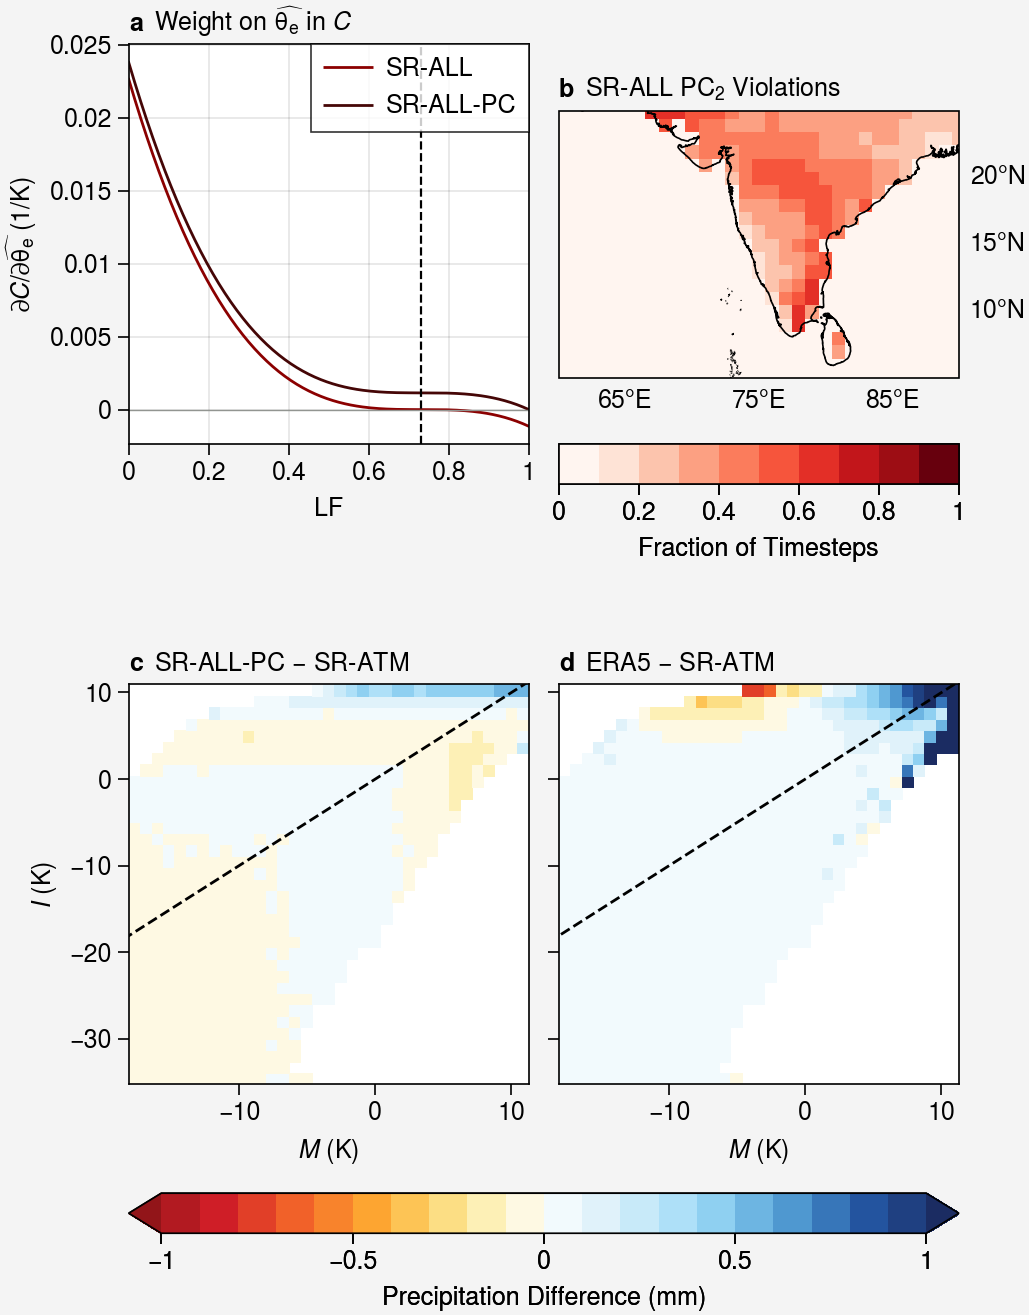

5.26


In [7]:
fig,axs = pplt.subplots([[1,2],[3,4]],refwidth=2,refheight=2,proj={2:'cyl'},share=False,wspace=1.2,hspace=8)
lfgrid = np.linspace(0,1,201)
for name in CONSTNAMES:
    axs[0].plot(lfgrid,calc_thetae_weight(lfgrid,consts[name]),color=EQUATIONS[name]['color'],linewidth=1,label=EQUATIONS[name]['description'])
axs[0].axhline(0,color='gray',linewidth=0.5)
axs[0].axvline(consts['sr_all_eq']['lfc'],color='k',linestyle='--',linewidth=0.8)
axs[0].legend(loc='ur',ncols=1)
axs[0].format(title='Weight on $\\widehat{\\theta_e}$ in $\\mathit{C}$',xlabel='LF',ylabel='$\\partial\\mathit{C}/\\partial\\widehat{\\theta_e}$ (1/K)',xlim=(0,1))
mviol = axs[1].pcolormesh(lon,lat,calc_time_mean(pc2grad['sr_all_eq']<0,finite,shape),cmap='Reds',vmin=0,vmax=1,levels=10)
axs[1].format(title='SR-ALL PC$_2$ Violations',coast=True,lonlim=LONRANGE,lonlines=[65,75,85],lonlabels='b',latlim=LATRANGE,latlines=[10,15,20],latlabels='r',grid=False)
axs[1].colorbar(mviol,loc='b',ticks=0.2,label='Fraction of Timesteps')
for ax,target,title in [(axs[2],pctp,'SR-ALL-PC $-$ SR-ATM'),(axs[3],tp,'ERA5 $-$ SR-ATM')]:
    mdiff = ax.pcolormesh(*micenters,bin_2d(moisture[finite],instability[finite],(target-atmtp)[finite],miedges).T,cmap='ColdHot_r',vmin=-1,vmax=1,levels=20,extend='both')
    ax.plot([min(mlim[0],ilim[0]),max(mlim[1],ilim[1])],[min(mlim[0],ilim[0]),max(mlim[1],ilim[1])],'k--',linewidth=1)
    ax.format(title=title,xlabel='$\\mathit{M}$ (K)',xlim=mlim,ylim=ilim)
axs[2].format(ylabel='$\\mathit{I}$ (K)')
axs[3].format(yticklabels=[])
fig.colorbar(mdiff,loc='b',cols=(1,2),label='Precipitation Difference (mm)',ticks=0.5)
fig.format(abc=True,titleloc='l')
pplt.show()
fig.save('../figs/fig_6_option_a.jpg')
print(round(fig.get_figwidth(),2))

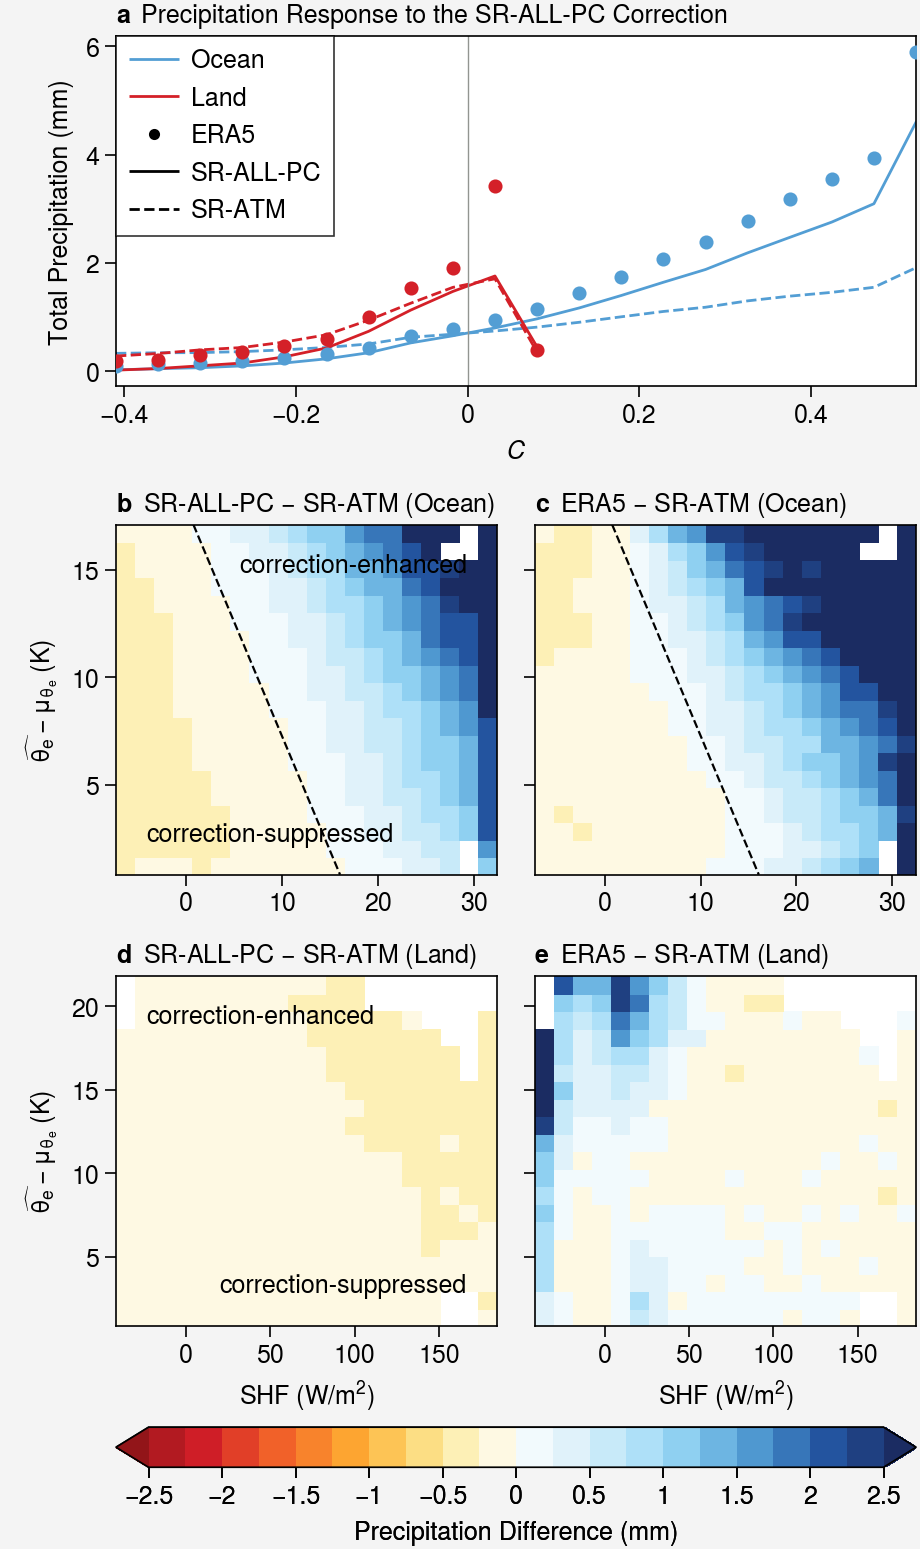

4.71


In [8]:
cedges   = np.linspace(*np.percentile(correction[favorable],[1,99]),FLUXBINS+1)
labelpos = {'Ocean':[(0.92,0.92,'right','top','correction-enhanced'),(0.08,0.08,'left','bottom','correction-suppressed')],
            'Land':[(0.08,0.92,'left','top','correction-enhanced'),(0.92,0.08,'right','bottom','correction-suppressed')]}

fig,axs = pplt.subplots(array=[[1,1],[2,3],[4,5]],refwidth=4,refheight=1.75,share=False,span=False,wspace=1.5)
for region,color in REGIONS.items():
    mask = favorable&regionmasks[region]
    centers,era5mean = bin_1d(correction[mask],tp[mask],cedges)
    _,pcmean         = bin_1d(correction[mask],pctp[mask],cedges)
    _,atmmean        = bin_1d(correction[mask],atmtp[mask],cedges)
    axs[0].scatter(centers,era5mean,color=color,markersize=20,zorder=3)
    axs[0].plot(centers,pcmean,color=color,linewidth=1,label=region)
    axs[0].plot(centers,atmmean,color=color,linestyle='--',linewidth=1)
for label,kwargs in [('ERA5',dict(marker='o',linestyle='none',markersize=3)),('SR-ALL-PC',dict(linewidth=1)),('SR-ATM',dict(linestyle='--',linewidth=1))]:
    axs[0].plot([],[],color='black',label=label,**kwargs)
axs[0].axvline(0,color='gray',linewidth=0.5)
axs[0].format(title='Precipitation Response to the SR-ALL-PC Correction',xlabel='$\\mathit{C}$',ylabel='Total Precipitation (mm)')
axs[0].legend(loc='ul',ncols=1)

for row,region in enumerate(REGIONS):
    mask    = favorable&regionmasks[region]
    edges   = (np.linspace(*np.percentile(shf[mask],[1,99]),FLUXBINS+1),np.linspace(*np.percentile(thetaeanom[mask],[1,99]),FLUXBINS+1))
    centers = [0.5*(edge[:-1]+edge[1:]) for edge in edges]
    gridshf,gridthetae = np.meshgrid(np.linspace(edges[0][0],edges[0][-1],200),np.linspace(edges[1][0],edges[1][-1],200))
    zerogrid = calc_correction_term(gridthetae+thetaemean,gridshf,np.median(lf[mask]),consts[PCNAME])
    for col,(target,title) in enumerate([(pctp,'SR-ALL-PC'),(tp,'ERA5')]):
        ax    = axs[1+2*row+col]
        mcorr = ax.pcolormesh(*centers,bin_2d(shf[mask],thetaeanom[mask],(target-atmtp)[mask],edges).T,cmap='ColdHot_r',vmin=-2.5,vmax=2.5,levels=20,extend='both')
        ax.contour(gridshf,gridthetae,zerogrid,levels=[0],colors='k',linewidths=0.8,linestyles='--')
        ax.format(title=f'{title} $-$ SR-ATM ({region})',xlim=(edges[0][0],edges[0][-1]),ylim=(edges[1][0],edges[1][-1]))
    for x,y,ha,va,label in labelpos[region]:
        axs[1+2*row].text(x,y,label,ha=ha,va=va,transform=axs[1+2*row].transAxes)
    axs[1+2*row].format(ylabel='$\\widehat{\\theta_e}-\\mu_{\\theta_e}$ (K)')
    axs[2+2*row].format(yticklabels=[])
axs[3:].format(xlabel='SHF (W/m$^2$)')
fig.colorbar(mcorr,loc='b',cols=(1,2),label='Precipitation Difference (mm)',ticks=0.5,pad=0.4)
fig.format(abc=True,titleloc='l',grid=False)
pplt.show()
fig.save('../figs/fig_6_option_b.jpg')
print(round(fig.get_figwidth(),2))

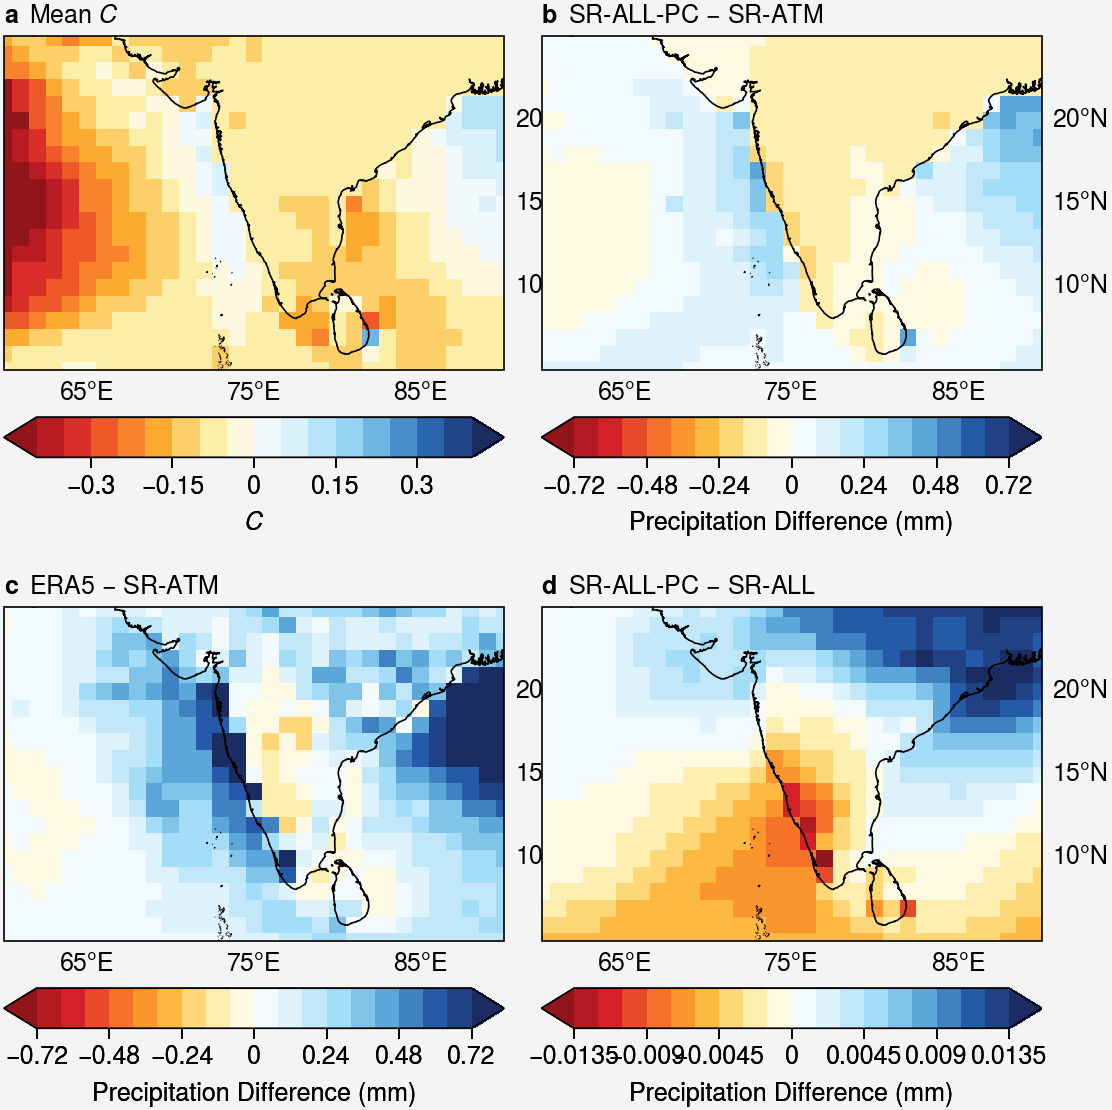

5.65
Domain-mean SR-ALL-PC - SR-ATM: 0.021 mm, ERA5 - SR-ATM: 0.213 mm, SR-ALL-PC - SR-ALL: 0.0007 mm


In [9]:
maps = {'corr':calc_time_mean(correction,finite,shape),
        'made':calc_time_mean(pctp-atmtp,finite,shape),
        'needed':calc_time_mean(tp-atmtp,finite,shape),
        'fix':calc_time_mean(pctp-predtp['sr_all_eq'],finite,shape)}
difflim = np.nanpercentile(np.abs(np.concatenate([maps['made'].ravel(),maps['needed'].ravel()])),98)
corrlim = np.nanpercentile(np.abs(maps['corr']),98)
fixlim  = np.nanpercentile(np.abs(maps['fix']),98)

fig,axs = pplt.subplots(nrows=2,ncols=2,proj='cyl',refwidth=2.5,wspace=1.5,hspace=6)
panels = [(maps['corr'],corrlim,'Mean $\\mathit{C}$','$\\mathit{C}$'),
          (maps['made'],difflim,'SR-ALL-PC $-$ SR-ATM','Precipitation Difference (mm)'),
          (maps['needed'],difflim,'ERA5 $-$ SR-ATM','Precipitation Difference (mm)'),
          (maps['fix'],fixlim,'SR-ALL-PC $-$ SR-ALL','Precipitation Difference (mm)')]
for ax,(field,lim,title,label) in zip(axs,panels):
    m = ax.pcolormesh(lon,lat,field,cmap='ColdHot_r',vmin=-lim,vmax=lim,levels=20,extend='both')
    ax.colorbar(m,loc='b',label=label)
    ax.format(title=title)
axs.format(coast=True,lonlim=LONRANGE,lonlines=[65,75,85],lonlabels='b',latlim=LATRANGE,latlines=[10,15,20],latlabels='r',grid=False,abc=True,titleloc='l')
pplt.show()
fig.save('../figs/fig_6_option_c.jpg')
print(round(fig.get_figwidth(),2))
print(f'Domain-mean SR-ALL-PC - SR-ATM: {np.nanmean(maps["made"]):.3f} mm, ERA5 - SR-ATM: {np.nanmean(maps["needed"]):.3f} mm, SR-ALL-PC - SR-ALL: {np.nanmean(maps["fix"]):.4f} mm')

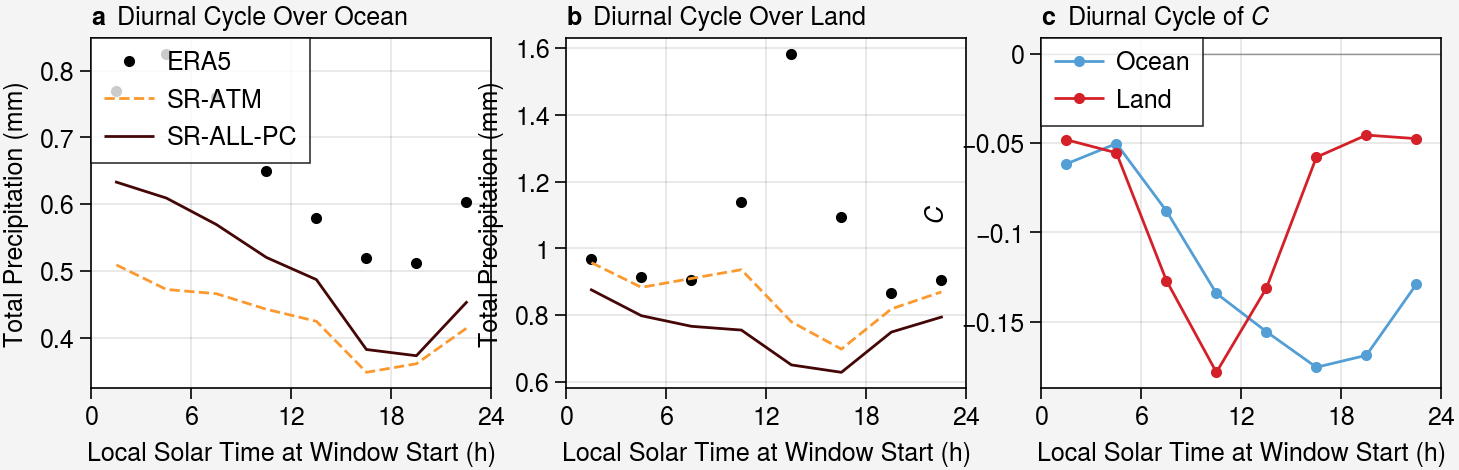

In [10]:
fig,axs = pplt.subplots(ncols=3,refwidth=2,refheight=1.75,share=False,wspace=3)
for ax,region in zip(axs[:2],REGIONS):
    mask = finite&regionmasks[region]
    ax.plot(hourcenters,bin_by_hour(hourbin,tp,mask),color='k',marker='o',markersize=3,linestyle='none',label='ERA5')
    ax.plot(hourcenters,bin_by_hour(hourbin,atmtp,mask),color=EQUATIONS['sr_atm_eq']['color'],linestyle='--',linewidth=1,label='SR-ATM')
    ax.plot(hourcenters,bin_by_hour(hourbin,pctp,mask),color=EQUATIONS[PCNAME]['color'],linewidth=1,label='SR-ALL-PC')
    ax.format(title=f'Diurnal Cycle Over {region}',ylabel='Total Precipitation (mm)')
axs[0].legend(loc='ul',ncols=1)
for region,color in REGIONS.items():
    axs[2].plot(hourcenters,bin_by_hour(hourbin,correction,finite&regionmasks[region]),color=color,linewidth=1,marker='o',markersize=3,label=region)
axs[2].axhline(0,color='gray',linewidth=0.5)
axs[2].legend(loc='ul',ncols=1)
axs[2].format(title='Diurnal Cycle of $\\mathit{C}$',ylabel='$\\mathit{C}$')
axs.format(xlabel='Local Solar Time at Window Start (h)',xlim=(0,24),xticks=6,abc=True,titleloc='l')
pplt.show()